# Part 9 — nnPU follow-up, Zadanie 2: seed-null distributions

Prerequisite for every later comparison in this follow-up (Zadania 3, 5, 6, 7): for every
metric used downstream (macro AP, Procrustes distance, linear CKA, `k`NN-overlap,
effective rank, RSA-Spearman), the spread across the 5 repetitions of the *same* ablation —
this is the detectability floor. No comparison in the later notebooks should be trusted unless
the between-variant effect exceeds the corresponding row here (`part_4`/`part_5`/`part_7`'s
established lesson in the original predictive-campaign analysis, applied from the start here).

**10 variants** (the two `_masked30` variants from the task spec are not yet trained — no
entropy-runs directory or checkpoints exist for them; Zadanie 4 is blocked on that separately):

| variant | campaign | grid | head loss |
|---|---|---|---|
| 0000 | `kidney-architecture-predictive` | `grid_0000` | `balanced_bce` |
| 0004 | `kidney-architecture-predictive` | `grid_0004` | `balanced_bce` |
| 0005 | `kidney-architecture-predictive` | `grid_0005` | `balanced_bce` |
| 0006 | `kidney-architecture-predictive` | `grid_0006` | `nnpu` (prior x1.5) |
| 0007 | `kidney-nnpu-objective-controls` | `grid_0000` | `bce` (no pos_weight) |
| 0008 | `kidney-nnpu-objective-controls` | `grid_0001` | `nnpu` (prior x1.5) |
| 0009 | `kidney-nnpu-prior-sensitivity` | `grid_0000` | `nnpu` (prior x1.0) |
| 0010 | `kidney-nnpu-prior-sensitivity` | `grid_0001` | `nnpu` (prior x2.0) |
| 0011 | `kidney-nnpu-objective-controls` | `grid_0002` | `bce` (no pos_weight) |
| 0012 | `kidney-nnpu-objective-controls` | `grid_0003` | `nnpu` (prior x1.5) |

All three campaigns share the identical `train`/`validation`/`test` split (verified directly
against each campaign's saved `config.json` — same seed 42, same grouped-by-`dataset_id`
assignment) — every geometric comparison below is row-aligned across all 10 variants directly,
no pixel-intersection trick needed.

**Methodological rules applied**: non-thresholded metrics only (macro AP, not F1/precision at a
fixed threshold — rule 1); macro-averaged only over classes with >=1 positive in `test`
(reported count included — rule 2); no comparison between BCE and nnPU *loss values* (rule 3 —
not computed here at all); geometry only on canonicalized $u=(z-\beta)/\gamma$ (rule 5).

In [1]:
import os
from dataclasses import replace
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.heads.metrics import evaluate_head
from msi_autoencoder_wrapper.analysis.autoencoder.latent import sphere_geometry as geometry
from msi_autoencoder_wrapper.visualization import resolve_theme

2026-08-28 14:55:18,942 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 14:55:18,945 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-08-28 14:55:19,721 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-08-28 14:55:19,722 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-08-28 14:55:19,724 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-08-28 14:55:19,725 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-28 14:55:19,745 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-08-28 14:55:19,882 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 14 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-08-28 14:55:19,883 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 18 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"

VARIANT_SPECS = {
    "0000": ("kidney-architecture-predictive__cfg_529dc0e4494b", "grid_0000"),
    "0004": ("kidney-architecture-predictive__cfg_529dc0e4494b", "grid_0004"),
    "0005": ("kidney-architecture-predictive__cfg_529dc0e4494b", "grid_0005"),
    "0006": ("kidney-architecture-predictive__cfg_529dc0e4494b", "grid_0006"),
    "0007": ("kidney-nnpu-objective-controls__cfg_0df14edbfadf", "grid_0000"),
    "0008": ("kidney-nnpu-objective-controls__cfg_0df14edbfadf", "grid_0001"),
    "0009": ("kidney-nnpu-prior-sensitivity__cfg_b89b9dfd127d", "grid_0000"),
    "0010": ("kidney-nnpu-prior-sensitivity__cfg_b89b9dfd127d", "grid_0001"),
    "0011": ("kidney-nnpu-objective-controls__cfg_0df14edbfadf", "grid_0002"),
    "0012": ("kidney-nnpu-objective-controls__cfg_0df14edbfadf", "grid_0003"),
}
REPETITIONS = range(5)
HEAD_NAME = "molecule_primary"
TARGET_FIELD = "molecule"
BATCH_SIZE = 256
PAIR_COUNT = 20000
KNN_K = 10
RANDOM_SEED = 42

RESULTS_DIRECTORY = Path("assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results")
RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)

theme = resolve_theme(None)
theme.apply()
model_colors = {variant: theme.color_for_model(variant, index) for index, variant in enumerate(VARIANT_SPECS)}
theme = replace(theme, model_overrides=model_colors)
theme.apply()

## Environment workaround

Every campaign's `config.json` bakes in the entropy compute node's `/tmp` path used at
training time — the same symlink target root works for all three (a single 20260824/20260827
scratch-workspace prefix, whichever the node used); if a fresh environment reports a missing
reader path, recreate the matching symlink from the offending `config.json`'s own path.

In [3]:
SCRATCH_ROOTS = [
    "/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace",
    "/tmp/ms488923/msi-wrapper/nnpu-controls-20260827/workspace",
    "/tmp/ms488923/msi-wrapper/nnpu-priors-20260827/workspace",
]
for scratch_root in SCRATCH_ROOTS:
    path = Path(scratch_root)
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.is_symlink():
        path.symlink_to(WORKSPACE.resolve())


## Row-aligned latent-code and logit extraction for all 10 variants x 5 repetitions on `test`

### Methodology
#### Theoretical
- Every downstream null (AP, geometry) requires the same `test` pixels, in the same order, across
  every (variant, repetition) pair evaluated — otherwise per-pixel/per-class alignment breaks
  silently. All three campaigns (`kidney-architecture-predictive`,
  `kidney-nnpu-objective-controls`, `kidney-nnpu-prior-sensitivity`) share the identical
  `train`/`validation`/`test` split (seed 42, grouped by `dataset_id`, verified against each
  campaign's own `config.json`), so `test_ids` fixed once from the first campaign loaded is valid
  for all three — no pixel-intersection step is needed.
- Latent geometry is only meaningful on the canonicalized code $u = (z-\beta)/\gamma$
  (methodological rule 5 of this follow-up), not the raw `latent_space` output, since
  $\gamma$/$\beta$ are the encoder's own final-layer-norm affine parameters and differ per model.

#### Implementation
- One `wrapper.load_configuration` per campaign (3 total) resolves that campaign's raw imzML
  reader and dataset context (~38-40 s each); every other (variant, repetition) sharing that
  campaign is then loaded with `wrapper.models_manager.load_model` (weights only, ~0.04 s each,
  per `../report/methodology.md`).
- For each (variant, repetition): `geometry.encoder_layer_norm_parameters(model)` retrieves
  $(\gamma, \beta)$; the model is run in `eval()` mode over `test` spectra (re-ordered by
  `test_ids` via `index_by_id`) in batches of `BATCH_SIZE=256`; `outputs["latent_space"]` is
  canonicalized with `geometry.canonicalize(z, gamma, beta)` into
  `u_by_variant_repetition[(variant, repetition)]`, and `outputs["head_molecule_primary"]` (raw
  logits) is stored in `logits_by_variant_repetition`.
- `targets_masks_by_campaign` is populated once per campaign from a plain `DataLoader` (batch 256,
  no shuffle) — this is in the dataset's own (unsorted) order, not `test_ids` order; explicitly
  fine for AP (order-independent per-class macro average) but **not** used for any row-aligned
  geometry computation.

### Notes
- All 10 variants encoded successfully; each reports 4023 `test` pixels
  (`"<variant>: encoded 5 repetitions on test (4023 pixels)"`), confirming the shared-split
  assumption holds in practice, not just on paper.


In [4]:
wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)

loaded_campaign_ids: set[str] = set()
test_ids: list[int] | None = None
u_by_variant_repetition: dict[tuple[str, int], np.ndarray] = {}
logits_by_variant_repetition: dict[tuple[str, int], np.ndarray] = {}
targets_masks_by_campaign: dict[str, tuple[np.ndarray, np.ndarray]] = {}
index_by_id_by_campaign: dict[str, dict[int, int]] = {}
test_dataset_by_campaign: dict[str, object] = {}

for variant, (campaign_id, grid_id) in VARIANT_SPECS.items():
    for repetition in REPETITIONS:
        model_name = f"{campaign_id}__{grid_id}__rep_0{repetition}"
        if campaign_id not in loaded_campaign_ids:
            wrapper.load_configuration(model_name=model_name)
            loaded_campaign_ids.add(campaign_id)
            partitions = wrapper.active_dataset.create_partitions()
            if test_ids is None:
                test_ids = sorted(partitions.manifest.assignments["test"])
            index_by_id = {sid: index for index, sid in enumerate(partitions.manifest.assignments["test"])}
            test_dataset = partitions.test
            index_by_id_by_campaign[campaign_id] = index_by_id
            test_dataset_by_campaign[campaign_id] = test_dataset
            model = wrapper.active_model
        else:
            model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
        model.eval()
        device = next(model.parameters()).device
        gamma, beta = geometry.encoder_layer_norm_parameters(model)

        ordered_indices = [index_by_id[sid] for sid in test_ids]
        spectra = torch.stack([test_dataset[index][1] for index in ordered_indices]).float()
        latents, logits_chunks = [], []
        with torch.no_grad():
            for start in range(0, len(spectra), BATCH_SIZE):
                batch = spectra[start : start + BATCH_SIZE].to(device)
                outputs = model(batch)
                latents.append(outputs["latent_space"].cpu().numpy())
                logits_chunks.append(outputs[f"head_{HEAD_NAME}"].cpu().numpy())
        z = np.concatenate(latents, axis=0)
        u_by_variant_repetition[(variant, repetition)] = geometry.canonicalize(z, gamma, beta)
        logits_by_variant_repetition[(variant, repetition)] = np.concatenate(logits_chunks, axis=0)

        if campaign_id not in targets_masks_by_campaign:
            target_batches, mask_batches = [], []
            loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
            for _, _, targets, masks in loader:
                target_batches.append(targets[TARGET_FIELD].numpy())
                mask_batches.append(masks[TARGET_FIELD].numpy())
            # NOTE: this is in the dataset's own (unsorted) test order, NOT `test_ids` order —
            # fine for AP (order-independent per-class macro average), NOT used for geometry.
            targets_masks_by_campaign[campaign_id] = (
                np.concatenate(target_batches, axis=0), np.concatenate(mask_batches, axis=0)
            )
    print(f"{variant}: encoded 5 repetitions on test ({len(test_ids)} pixels)")

2026-08-28 14:55:20,490 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-08-28 14:55:20,492 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-08-28 14:55:20,493 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-08-28 14:55:20,494 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 14:55:20,495 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-08-28 15:01:03,834 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-08-28 15:01:03,835 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-08-28 15:01:03,839 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-28 15:01:03,844 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


0012: encoded 5 repetitions on test (4023 pixels)


## Macro average-precision seed-to-seed null (per variant, across 5 repetitions)

### Methodology
#### Theoretical
- Establishes the detectability floor for the `average_precision` metric: the spread across 5
  repetitions of the *same* ablation, which any between-variant AP difference examined later
  (Zadania 3/5/6/7) must clear to be considered a real effect rather than seed noise.
- Non-thresholded metric only (methodological rule 1 — macro AP, not F1/precision at a fixed
  decision threshold).
- Macro-averaged only over classes with `positive_samples >= 1` on `test` (rule 2); since all
  three campaigns share the identical split, they share one active-class set for `molecule` —
  reported once per campaign rather than per variant.

#### Implementation
- Active-class count per campaign: `active = (targets * mask).sum(axis=0) > 0`, printed as
  `<active>/<total>` classes.
- Per (variant, repetition): `evaluate_head(logits, targets, "multi_label", mask, threshold=0.5)`
  — despite the `threshold` argument, only its `average_precision` output (which does not depend
  on the threshold) is used, consistent with rule 1.
- `ap_frame` (variant, repetition, average_precision) is grouped by `variant` and aggregated with
  `mean`/`std`/`min`/`max` across the 5 repetitions into `ap_summary`.
- The violin+scatter plot below (`visualization.metrics.plot_violin_with_points`) shows the actual
  5 per-repetition values per variant directly, rather than only the mean/std/min/max table.

### Notes
- All three campaigns report the identical active-class count: 113/508 classes active on `test`,
  confirming the shared-split assumption for this specific check.
- AP null width (std across 5 reps) is typically small (0.008-0.020) for most variants, e.g.
  `0004` (std 0.0103), `0010` (std 0.0076).
- `0011` is a clear outlier: std 0.0672 — roughly 4-6x every other variant — with individual
  repetitions ranging from 0.298 to 0.468 (mean 0.398).
- Variant means range from 0.246 (`0007`, lowest) to 0.398 (`0011`, highest, but also the least
  stable — see above).
- `0007` (mean 0.246, std 0.0117 — normal-width null) sits well below every other variant,
  including its only other "no `pos_weight`" sibling `0011` (mean 0.398).


In [5]:
for campaign_id, (targets, mask) in targets_masks_by_campaign.items():
    active = ((targets * mask).sum(axis=0) > 0)
    print(f"{campaign_id}: {int(active.sum())}/{targets.shape[1]} classes active on test")

ap_rows = []
for variant, (campaign_id, grid_id) in VARIANT_SPECS.items():
    targets, mask = targets_masks_by_campaign[campaign_id]
    for repetition in REPETITIONS:
        logits = logits_by_variant_repetition[(variant, repetition)]
        metrics = evaluate_head(logits, targets, "multi_label", mask, threshold=0.5)
        ap_rows.append({"variant": variant, "repetition": repetition, "average_precision": metrics["average_precision"]})

ap_frame = pd.DataFrame(ap_rows)
ap_summary = ap_frame.groupby("variant")["average_precision"].agg(["mean", "std", "min", "max"])
ap_summary

kidney-architecture-predictive__cfg_529dc0e4494b: 113/508 classes active on test
kidney-nnpu-objective-controls__cfg_0df14edbfadf: 113/508 classes active on test
kidney-nnpu-prior-sensitivity__cfg_b89b9dfd127d: 113/508 classes active on test


,mean,std,min,max
variant,,,,
0000,0.364260,0.016666,0.345492,0.385860
0004,0.357359,0.010295,0.340702,0.365946
0005,0.352058,0.016371,0.335600,0.371649
0006,0.347384,0.013176,0.326019,0.356072
0007,0.246376,0.011677,0.233426,0.263656
0008,0.343618,0.011103,0.325481,0.354249
0009,0.321254,0.014805,0.299233,0.340879
0010,0.352760,0.007557,0.340316,0.359788
0011,0.398353,0.067157,0.298032,0.468288


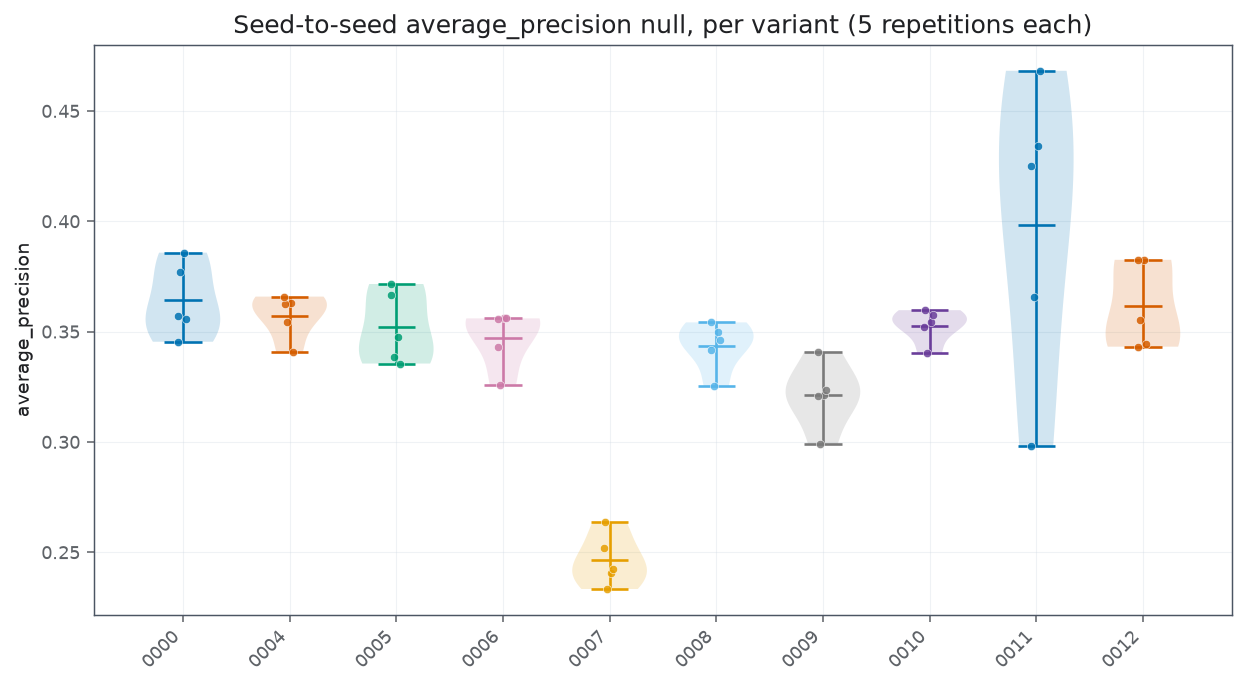

In [6]:
import matplotlib.pyplot as plt

from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

figure, axis = plt.subplots(figsize=(9.0, 5.0), dpi=theme.figure_dpi)
variants = list(VARIANT_SPECS)
for index, variant in enumerate(variants):
    values = ap_frame.loc[ap_frame["variant"] == variant, "average_precision"].to_numpy()
    plot_violin_with_points(values, position=index, ax=axis, width=0.7, color=theme.color_for_model(variant, index))
axis.set_xticks(range(len(variants)))
axis.set_xticklabels(variants, rotation=45, ha="right")
axis.set(ylabel="average_precision", title="Seed-to-seed average_precision null, per variant (5 repetitions each)")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()

## Latent-geometry seed-to-seed nulls: structure, dimension, RSA (single-model metrics)

### Methodology
#### Theoretical
- Same detectability-floor logic as the AP null above, applied to five single-model
  latent-geometry metrics computed independently per repetition (no second model required for
  the metric itself): `sd_cos_theta` (structure), `effective_rank` and `participation_ratio`
  (dimension usage), `two_nn_intrinsic_dimension` (TwoNN), and `rsa_spearman_r` (representational
  similarity to labels).
- Computed on the canonicalized latent code $u$ only (rule 5).

#### Implementation
- `geometry.structure_test(u, structure_rng, pair_count=min(PAIR_COUNT, N*(N-1)))` returns
  `observed_sd_cos_theta`; `geometry.dimension_usage(u)` returns
  `effective_rank`/`participation_ratio`; `geometry.two_nn_intrinsic_dimension(u)` computes the
  TwoNN estimator; `geometry.rsa_spearman(u, labels, rsa_rng, pair_count=...)` returns
  `spearman_r` between representational (dis)similarity and label overlap. `PAIR_COUNT=20000`,
  capped at $N(N-1)$ for the 4023-pixel `test` set. `structure_rng`/`rsa_rng` are separate
  `np.random.default_rng` instances seeded `RANDOM_SEED+1`/`RANDOM_SEED+2`.
- Labels for RSA are rebuilt per campaign directly from `test_dataset[index][2][TARGET_FIELD]`,
  re-ordered to match `test_ids` — reusing the `index_by_id`/`test_dataset_by_campaign` captured
  during the main loading loop above, no extra `load_configuration` needed.
- Results collected into `single_model_frame` (variant, repetition, metric, value), grouped by
  `(variant, metric)` and aggregated with `mean`/`std`/`min`/`max` across the 5 repetitions.
- The violin+scatter grid below (one panel per metric, `visualization.metrics.plot_violin_with_points`)
  shows the actual 5 per-repetition values per variant directly, rather than only this table.

### Notes
- Confirms and extends the original predictive-campaign's `part_7` finding across all 10
  nnPU-family variants: variants without `+contractive` (`0000`, `0011`, `0012`) show
  `sd_cos_theta` means in 0.449-0.457, while all seven `+contractive` variants (`0004`-`0010`)
  show means in 0.026-0.029 — over an order of magnitude tighter, with no overlap between the two
  groups' min/max ranges.
- `two_nn_intrinsic_dimension` shows the same two-cluster split: 5.73-5.79 (mean) for the
  non-contractive group vs. 5.16-5.23 for the contractive group.
- `effective_rank` (2.39-2.48) and `participation_ratio` (1.72-1.77) vary much less between the
  two groups than `sd_cos_theta`/TwoNN do — the split is visible but far less sharp on these two
  metrics.
- `rsa_spearman_r` also separates the two groups: 0.68-0.69 (non-contractive: `0000`, `0011`,
  `0012`) vs. 0.64-0.65 (contractive: `0004`-`0010`).
- Per-metric seed-to-seed std is generally small relative to the between-group gap (e.g.
  `sd_cos_theta` std 0.003-0.004 for the contractive group against a ~0.42-0.43 gap to the
  non-contractive group's ~0.45 mean) — the detectability floor is comfortably cleared for this
  particular contrast.


In [7]:
structure_rng = np.random.default_rng(RANDOM_SEED + 1)
rsa_rng = np.random.default_rng(RANDOM_SEED + 2)

# Rebuild row-aligned test labels once per campaign, matching `test_ids` order exactly —
# reuses the index_by_id/test_dataset captured during the main loading loop above, no
# extra `load_configuration` reload needed.
labels_by_campaign: dict[str, np.ndarray] = {}
for campaign_id, index_by_id in index_by_id_by_campaign.items():
    test_dataset = test_dataset_by_campaign[campaign_id]
    ordered_indices = [index_by_id[sid] for sid in test_ids]
    labels_by_campaign[campaign_id] = np.stack([test_dataset[index][2][TARGET_FIELD].numpy() for index in ordered_indices])

single_model_rows = []
for variant, (campaign_id, grid_id) in VARIANT_SPECS.items():
    labels = labels_by_campaign[campaign_id]
    for repetition in REPETITIONS:
        u = u_by_variant_repetition[(variant, repetition)]
        structure = geometry.structure_test(u, structure_rng, pair_count=min(PAIR_COUNT, u.shape[0] * (u.shape[0] - 1)))
        dimension = geometry.dimension_usage(u)
        two_nn = geometry.two_nn_intrinsic_dimension(u)
        rsa = geometry.rsa_spearman(u, labels, rsa_rng, pair_count=min(PAIR_COUNT, u.shape[0] * (u.shape[0] - 1)))
        for metric_name, value in (
            ("sd_cos_theta", structure["observed_sd_cos_theta"]),
            ("effective_rank", dimension["effective_rank"]),
            ("participation_ratio", dimension["participation_ratio"]),
            ("two_nn_intrinsic_dimension", two_nn),
            ("rsa_spearman_r", rsa["spearman_r"]),
        ):
            single_model_rows.append({"variant": variant, "repetition": repetition, "metric": metric_name, "value": value})
    print(f"{variant}: geometry computed")

single_model_frame = pd.DataFrame(single_model_rows)
single_model_null = single_model_frame.groupby(["variant", "metric"])["value"].agg(["mean", "std", "min", "max"])
single_model_null


0000: geometry computed


0004: geometry computed


0005: geometry computed


0006: geometry computed


0007: geometry computed


...

0009: geometry computed


0010: geometry computed


0011: geometry computed


0012: geometry computed


mean       std       min       max
variant metric                                                            
0000    effective_rank              2.484595  0.174037  2.242378  2.670456
        participation_ratio         1.748386  0.137095  1.530813  1.892018
        rsa_spearman_r              0.682265  0.025442  0.645825  0.716106
        sd_cos_theta                0.456799  0.035804  0.425667  0.509232
        two_nn_intrinsic_dimension  5.730707  0.109086  5.628472  5.915435
0004    effective_rank              2.433302  0.169850  2.225066  2.633300
        participation_ratio         1.768623  0.147412  1.609513  1.954805
        rsa_spearman_r              0.647138  0.020851  0.615418  0.666090
        sd_cos_theta                0.027119  0.003918  0.021356  0.030907
        two_nn_intrinsic_dimension  5.205345  0.028390  5.169387  5.243129
0005    effective_rank              2.392434  0.175449  2.131878  2.589331
        participation_ratio         1.733562  0.138349  1.550044  1.902796
        rsa_spearman_r              0.649572  0.021310  0.620576  0.668293
        sd_cos_theta                0.027969  0.003655  0.024617  0.032318
        two_nn_intrinsic_dimension  5.162833  0.068416  5.107139  5.263434
0006    effective_rank              2.402421  0.170955  2.256883  2.668847
        participation_ratio         1.739790  0.146033  1.618590  1.972786
        rsa_spearman_r              0.650380  0.025504  0.613069  0.682966
        sd_cos_theta                0.026819  0.003922  0.022195  0.030803
        two_nn_intrinsic_dimension  5.209038  0.077821  5.146421  5.306172
0007    effective_rank              2.385804  0.169699  2.157656  2.621309
        participation_ratio         1.721138  0.132247  1.566830  1.922950
        rsa_spearman_r              0.642698  0.028020  0.611101  0.674412
        sd_cos_theta                0.028514  0.003959  0.024279  0.033093
        two_nn_intrinsic_dimension  5.166473  0.045746  5.113189  5.231662
0008    effective_rank              2.408583  0.150688  2.169988  2.559761
        participation_ratio         1.737856  0.118349  1.570285  1.857530
        rsa_spearman_r              0.649775  0.023068  0.620593  0.680049
        sd_cos_theta                0.026745  0.004036  0.022770  0.032832
        two_nn_intrinsic_dimension  5.225766  0.056958  5.131307  5.271260
0009    effective_rank              2.402285  0.149919  2.205754  2.575037
        participation_ratio         1.738924  0.123349  1.602153  1.896811
        rsa_spearman_r              0.649083  0.021517  0.626293  0.678573
        sd_cos_theta                0.026436  0.003189  0.022097  0.030037
        two_nn_intrinsic_dimension  5.193982  0.068392  5.133847  5.307536
0010    effective_rank              2.387187  0.165809  2.145124  2.556308
        participation_ratio         1.727261  0.135078  1.552093  1.878645
        rsa_spearman_r              0.642238  0.016204  0.620560  0.662967
        sd_cos_theta                0.027571  0.004275  0.021911  0.032139
        two_nn_intrinsic_dimension  5.201206  0.046752  5.141902  5.248195
0011    effective_rank              2.444116  0.102505  2.284200  2.531273
        participation_ratio         1.731982  0.107879  1.585797  1.850120
        rsa_spearman_r              0.681587  0.011863  0.671402  0.699766
        sd_cos_theta                0.448993  0.027023  0.420114  0.482241
        two_nn_intrinsic_dimension  5.786251  0.051148  5.746295  5.874504
0012    effective_rank              2.457976  0.156134  2.242576  2.605430
        participation_ratio         1.736985  0.117734  1.546869  1.852919
        rsa_spearman_r              0.685954  0.019200  0.666511  0.716684
        sd_cos_theta                0.457172  0.029893  0.430758  0.494991
        two_nn_intrinsic_dimension  5.755282  0.093483  5.661498  5.868414

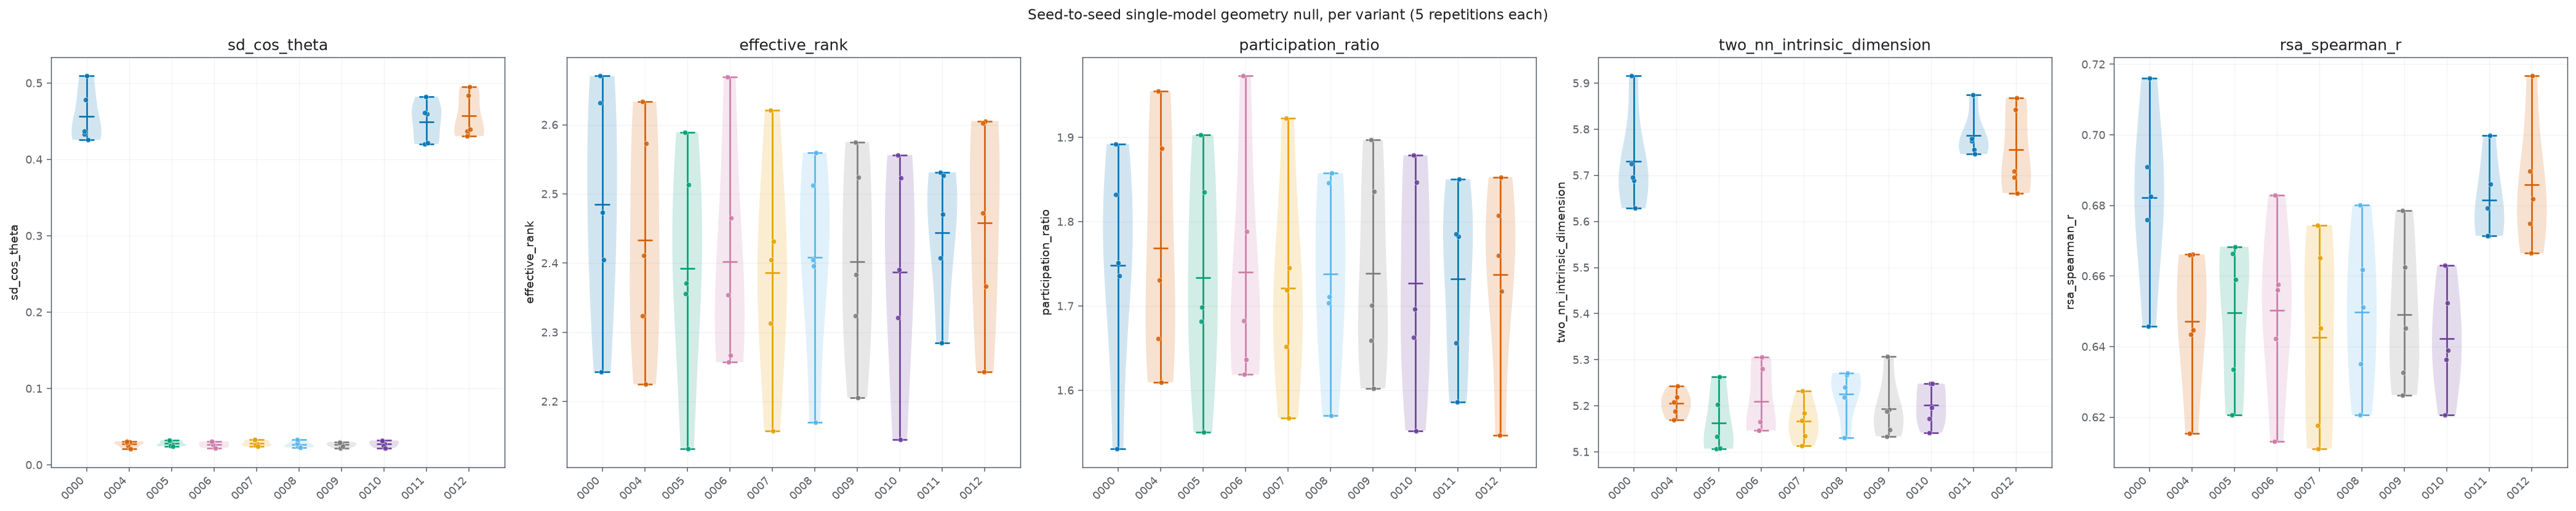

In [8]:
import matplotlib.pyplot as plt

from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

single_model_metric_names = ["sd_cos_theta", "effective_rank", "participation_ratio", "two_nn_intrinsic_dimension", "rsa_spearman_r"]
variants = list(VARIANT_SPECS)
figure, axes = plt.subplots(1, len(single_model_metric_names), figsize=(30.0, 6.0), dpi=theme.figure_dpi)
for axis, metric_name in zip(axes, single_model_metric_names):
    for index, variant in enumerate(variants):
        values = single_model_frame.loc[
            (single_model_frame["variant"] == variant) & (single_model_frame["metric"] == metric_name), "value"
        ].to_numpy()
        plot_violin_with_points(values, position=index, ax=axis, width=0.7, color=theme.color_for_model(variant, index))
    axis.set_xticks(range(len(variants)))
    axis.set_xticklabels(variants, rotation=45, ha="right")
    axis.set(ylabel=metric_name, title=metric_name)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle("Seed-to-seed single-model geometry null, per variant (5 repetitions each)", fontsize=12)
figure.tight_layout()

## Latent-geometry seed-to-seed nulls: Procrustes, CKA, `k`NN-overlap (pairwise-across-repetitions metrics)

### Methodology
#### Theoretical
- Complements the single-model nulls above with metrics that inherently compare two repetitions'
  latent geometries against each other: Procrustes distance (alignment cost after optimal
  rotation/reflection/scaling), linear CKA (representational similarity independent of orthogonal
  transform), and `k`NN-overlap (neighborhood-structure agreement). These have no single-model
  analogue, so the null is built across repetition *pairs* of the same variant rather than across
  individual repetitions.
- Same convention as `part_7`: within-variant null from all $\binom{5}{2}=10$ repetition pairs, on
  the same canonicalized `test` codes $u$ used above.

#### Implementation
- For each variant, iterates `itertools.combinations(REPETITIONS, 2)` (10 pairs):
  `geometry.procrustes_distance(u_a, u_b)`, `geometry.linear_cka(u_a, u_b)`,
  `geometry.knn_overlap(u_a, u_b, k=min(KNN_K, N-1))` with `KNN_K=10`.
- `pairwise_null_frame` (variant, rep_pair, procrustes_distance, linear_cka, knn_overlap) grouped
  by `variant`, aggregated `mean`/`std`/`min`/`max` per metric across the 10 pairs.
- The violin+scatter grid below (one panel per metric, `visualization.metrics.plot_violin_with_points`)
  shows the actual 10 per-repetition-pair values per variant directly, rather than only this table.

### Notes
- `procrustes_distance` means range from 0.172 (`0009`) to 0.247 (`0000`); the non-contractive
  variants (`0000`, `0011`, `0012`: means 0.247, 0.207, 0.203) sit noticeably higher than most
  contractive variants (`0004`-`0010`: means 0.172-0.187), consistent with looser cross-seed
  alignment for the non-contractive group.
- `linear_cka` means are uniformly high (0.979-0.989) across all variants — cross-seed
  representational similarity is strong everywhere, with only a narrow spread between variants.
- `knn_overlap` shows the same two-cluster split already seen in the single-model nulls:
  non-contractive variants (`0000`, `0011`, `0012`) mean 0.506-0.513, contractive variants
  (`0004`-`0010`) mean 0.616-0.627 — the contractive cluster's neighborhood structure is *more*
  reproducible across seeds, not less, matching the direction of the original campaign's finding.


In [9]:
pairwise_null_rows = []
for variant in VARIANT_SPECS:
    for rep_a, rep_b in combinations(REPETITIONS, 2):
        u_a = u_by_variant_repetition[(variant, rep_a)]
        u_b = u_by_variant_repetition[(variant, rep_b)]
        knn_k = min(KNN_K, u_a.shape[0] - 1)
        pairwise_null_rows.append({
            "variant": variant, "rep_pair": f"{rep_a}-{rep_b}",
            "procrustes_distance": geometry.procrustes_distance(u_a, u_b),
            "linear_cka": geometry.linear_cka(u_a, u_b),
            "knn_overlap": geometry.knn_overlap(u_a, u_b, k=knn_k),
        })

pairwise_null_frame = pd.DataFrame(pairwise_null_rows)
pairwise_null_summary = pairwise_null_frame.groupby("variant")[["procrustes_distance", "linear_cka", "knn_overlap"]].agg(["mean", "std", "min", "max"])
pairwise_null_summary

procrustes_distance                               linear_cka  \
                       mean       std       min       max       mean   
variant                                                                
0000               0.247221  0.058859  0.158206  0.315757   0.978560   
0004               0.179507  0.022019  0.146198  0.206286   0.986020   
0005               0.180645  0.020879  0.142221  0.209634   0.987141   
0006               0.187345  0.026253  0.154450  0.235353   0.983178   
0007               0.186915  0.026467  0.155657  0.221799   0.983839   
0008               0.171636  0.015285  0.145968  0.202817   0.988657   
0009               0.171610  0.020201  0.145503  0.202108   0.988189   
0010               0.185080  0.019928  0.159686  0.214653   0.985500   
0011               0.207453  0.025604  0.174964  0.255034   0.987852   
0012               0.203167  0.026344  0.163747  0.246706   0.986792   

                                      knn_overlap                      \
              std       min       max        mean       std       min   
variant                                                                 
0000     0.014218  0.954094  0.992339    0.507355  0.016917  0.484116   
0004     0.005963  0.975824  0.993754    0.627020  0.016944  0.595700   
0005     0.004354  0.979746  0.994232    0.619478  0.016556  0.591250   
0006     0.006430  0.970352  0.993111    0.615712  0.019319  0.587745   
0007     0.005799  0.976191  0.992548    0.618295  0.017272  0.594034   
0008     0.002956  0.982467  0.992545    0.618829  0.019457  0.591350   
0009     0.004528  0.981498  0.994344    0.624865  0.017362  0.603828   
0010     0.004328  0.978367  0.991954    0.618409  0.012665  0.593338   
0011     0.005737  0.977250  0.993873    0.506376  0.008214  0.492319   
0012     0.007201  0.968791  0.994251    0.513207  0.010938  0.492866   

                   
              max  
variant            
0000     0.534203  
0004     0.654362  
0005     0.648919  
0006     0.643748  
0007     0.639697  
0008     0.651181  
0009     0.647328  
0010     0.638056  
0011     0.519215  
0012     0.530475

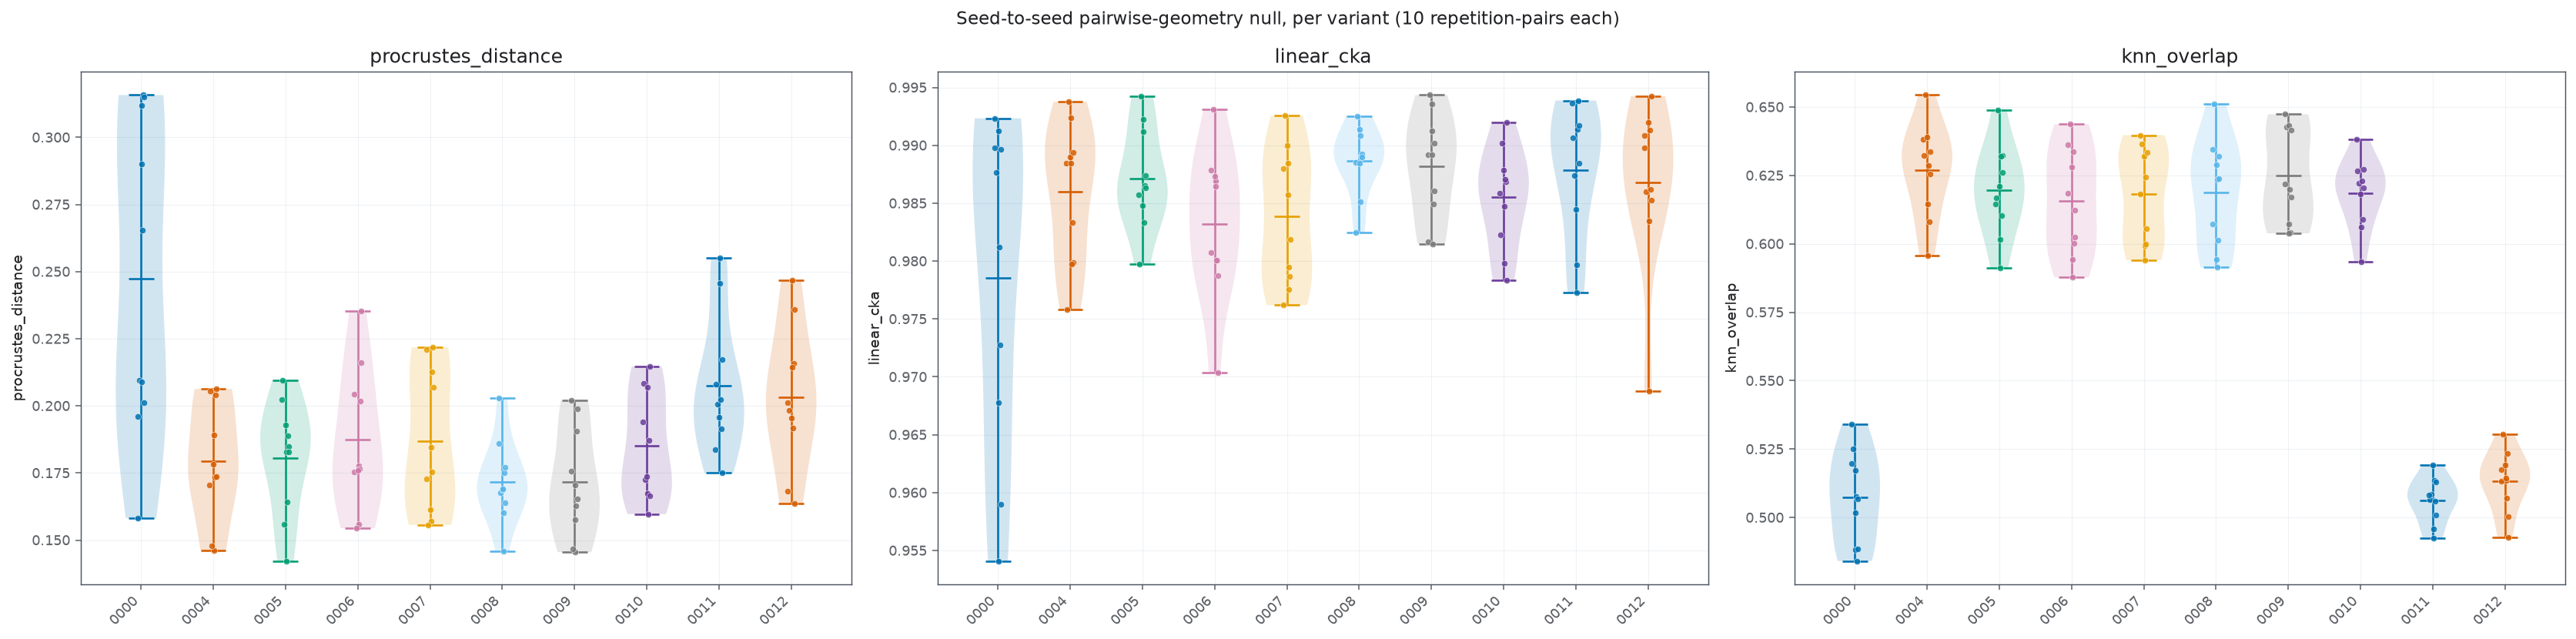

In [10]:
import matplotlib.pyplot as plt

from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

pairwise_metric_names = ["procrustes_distance", "linear_cka", "knn_overlap"]
variants = list(VARIANT_SPECS)
figure, axes = plt.subplots(1, len(pairwise_metric_names), figsize=(24.0, 6.0), dpi=theme.figure_dpi)
for axis, metric_name in zip(axes, pairwise_metric_names):
    for index, variant in enumerate(variants):
        values = pairwise_null_frame.loc[pairwise_null_frame["variant"] == variant, metric_name].to_numpy()
        plot_violin_with_points(values, position=index, ax=axis, width=0.7, color=theme.color_for_model(variant, index))
    axis.set_xticks(range(len(variants)))
    axis.set_xticklabels(variants, rotation=45, ha="right")
    axis.set(ylabel=metric_name, title=metric_name)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle("Seed-to-seed pairwise-geometry null, per variant (10 repetition-pairs each)", fontsize=12)
figure.tight_layout()

## Save `seed_null_distribution.csv`

Long form, `campaign, variant, repetition, metryka, wartość` — `repetition` holds a single
repetition index for single-model metrics (AP, structure, dimension, TwoNN, RSA) and a
`"i-j"` pair string for the pairwise geometry metrics (Procrustes/CKA/`k`NN-overlap), matching
`part_7`'s `rep_pair` convention.

In [11]:
null_rows = []
for variant, (campaign_id, grid_id) in VARIANT_SPECS.items():
    for repetition in REPETITIONS:
        ap_value = ap_frame.loc[(ap_frame["variant"] == variant) & (ap_frame["repetition"] == repetition), "average_precision"].iloc[0]
        null_rows.append({"campaign": campaign_id, "variant": variant, "repetition": repetition, "metryka": "average_precision", "wartość": ap_value})
    for _, row in single_model_frame[single_model_frame["variant"] == variant].iterrows():
        null_rows.append({"campaign": campaign_id, "variant": variant, "repetition": row["repetition"], "metryka": row["metric"], "wartość": row["value"]})
    for _, row in pairwise_null_frame[pairwise_null_frame["variant"] == variant].iterrows():
        for metric_name in ("procrustes_distance", "linear_cka", "knn_overlap"):
            null_rows.append({"campaign": campaign_id, "variant": variant, "repetition": row["rep_pair"], "metryka": metric_name, "wartość": row[metric_name]})

seed_null_frame = pd.DataFrame(null_rows)
seed_null_frame.to_csv(RESULTS_DIRECTORY / "seed_null_distribution.csv", index=False)
print(f"wrote {RESULTS_DIRECTORY / 'seed_null_distribution.csv'} ({len(seed_null_frame)} rows)")

wrote assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results/seed_null_distribution.csv (600 rows)


## Notes for the next pass

**Headline 1: the contractive-driven two-cluster geometric split from the original
predictive-campaign analysis (`part_7`) generalizes across the entire 10-variant nnPU
family, not just the original 4 objectives.** `sd_cos_theta`: the three variants
without `+contractive` (`0000`, `0011`, `0012`) sit at 0.449-0.457; all seven with
`+contractive` (`0004`-`0010`) sit at 0.026-0.029 — over an order of magnitude tighter,
with zero overlap. `two_nn_intrinsic_dimension` shows the same split (5.73-5.79 vs.
5.16-5.23), as does `knn_overlap`'s own seed-to-seed null (~0.51 vs. ~0.615-0.627 —
the contractive-cluster's neighborhood structure is *more* reproducible across seeds,
matching the original campaign's finding). Zadanie 7 should treat this as the
confirmed baseline pattern to check any nnPU-specific deviation against, not a new
finding to rediscover.

**Headline 2: the AP null is very uneven across variants — `0011` is a clear outlier.**
Most variants' `average_precision` std sits at 0.008-0.020 across 5 repetitions;
`0011` (bare `bce`, no pos_weight, no regularizers) sits at **0.067** — roughly 4-6x
wider than everything else, with individual repetitions ranging from 0.298 to 0.468.
Any comparison in Zadanie 5 that includes `0011` (`0000` vs. `0011`; the `0011` vs.
`0012` mechanism test in `part_10`) must be read against *this* wide a null, not the
typical ~0.01-0.02 — a modest-looking mean difference could easily be noise here.

**Descriptive lead worth flagging for Zadanie 5**: `0007`'s macro AP (0.246, std 0.012
— a *normal*-width null, unlike `0011`) sits well below every other variant, including
its only other "no pos_weight" sibling `0011` (0.398). `0007` and `0011` share the
same head loss (plain `bce`, no `pos_weight`) and differ only in
`+contractive+InfoNCE label-invariant` — so this pair is precisely Zadanie 5's `0007`
vs. `0011`-style "pure regularizer effect" comparison, and the gap (0.152) is roughly
2x `0011`'s own null width — plausibly real, but `0011`'s instability means this needs
the full paired-by-repetition treatment in `part_12`, not just the pooled means here.

**Artifact**: `seed_null_distribution.csv` (600 rows: 10 variants x 5 metrics x 5
repetitions for single-model metrics, plus 10 variants x 3 metrics x 10 repetition
pairs for Procrustes/CKA/`k`NN-overlap).